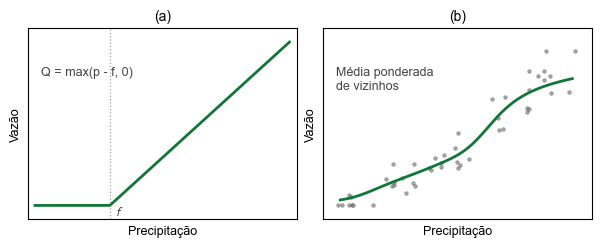

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stixsans",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
})

cm = 1 / 2.54
VERDE = "#117738"
CINZA = "#444444"
MEAN = "#9e9e9e"

F = 3.0   # capacidade de infiltração (parâmetro físico)

fig, (ax_fis, ax_dad) = plt.subplots(
    1, 2, figsize=(15 * cm, 6.0 * cm), layout="constrained"
)

# Moldura comum: rótulo do painel, eixos nomeados e sem ticks
for ax, rotulo in ((ax_fis, "(a)"), (ax_dad, "(b)")):
    ax.set_title(rotulo)
    ax.set_xlabel("Precipitação")
    ax.set_ylabel("Vazão")
    ax.set_xticks([])
    ax.set_yticks([])

# ---------------------------- Painel (a): baseado em física --------------------
# Curva derivada de uma equação simples (excesso de infiltração)
P = np.linspace(0.0, 10.2, 300)
Q_fis = np.clip(P - F, 0.0, None)

ax_fis.axvline(F, color=MEAN, lw=0.9, ls=":", zorder=1)   # limiar de infiltração
ax_fis.plot(P, Q_fis, color=VERDE, linewidth=2.0, zorder=3)
ax_fis.set_xlim(-0.3, 10.5)
ax_fis.set_ylim(-0.6, 7.8)
ax_fis.text(F + 0.2, -0.55, r"$f$", color=CINZA, fontsize=9,
            ha="left", va="bottom")
ax_fis.text(0.05, 0.80, "Q = max(p - f, 0)", transform=ax_fis.transAxes,
            fontsize=9, ha="left", va="top", color=CINZA)

# ---------------------------- Painel (b): orientado a dados --------------------
# Nuvem (P, Q) e curva ajustada por suavização, SEM fórmula imposta
rng = np.random.default_rng(5)
P_obs = np.sort(rng.uniform(0.3, 9.8, 48))

# Relação real (fuzzy) da qual os pontos são sorteados com ruído crescente
s = 0.9
tendencia = s * np.log1p(np.exp((P_obs - 2.6) / s))
dispersao = 0.30 + 0.08 * P_obs
Q_obs = tendencia + rng.normal(0.0, 1.0, P_obs.size) * dispersao
Q_obs = np.clip(Q_obs, 0.02, 6.8)
ax_dad.scatter(P_obs, Q_obs, c="gray", s=7, alpha=0.7,
               edgecolors="black", linewidth=0.2, zorder=2)


def suavizacao_kernel(xq, x, y, bw):
    # Ajuste não paramétrico: média local ponderada (sem forma pré-definida)
    W = np.exp(-0.5 * ((xq[:, None] - x[None, :]) / bw) ** 2)
    return (W * y[None, :]).sum(axis=1) / W.sum(axis=1)


P_grid = np.linspace(0.4, 9.7, 220)
Q_fit = suavizacao_kernel(P_grid, P_obs, Q_obs, bw=1.05)
ax_dad.plot(P_grid, Q_fit, color=VERDE, linewidth=2.0, zorder=3)
ax_dad.set_xlim(-0.3, 10.5)
ax_dad.set_ylim(-0.6, 7.8)
ax_dad.text(0.05, 0.80, "Média ponderada\nde vizinhos", transform=ax_dad.transAxes,
            fontsize=9, ha="left", va="top", color=CINZA)

fig.savefig("figuras/exemplo_modelos_dicotomia.png", dpi=300)
